<a href="https://colab.research.google.com/github/SrilathaWeb/Data-Science-Cohort-20/blob/main/housing_price_prediction_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2: Housing Price Prediction

## Table of Contents
1. Problem Definition
2. Data Collections
3. Exploratory Data Analysis
4. Data Cleaning
5. Processing
6. Data Visualization / Communication of Results

This notebook builds a full regression workflow for predicting house sale prices with:
- `LinearRegression`
- `Ridge`
- `Lasso`

The project goal is to minimize **RMSPE (Root Mean Squared Percentage Error)** while also documenting the data science process clearly.


## Problem Definition

The task is to predict `SalePrice` for homes in the housing dataset. Since the project specifically asks for regression with **feature scaling** and **regularization**, the notebook compares:

- A baseline `LinearRegression`
- `Ridge` regression with L2 regularization
- `Lasso` regression with L1 regularization

Model quality is evaluated primarily with **RMSPE**, because it measures percentage-based prediction error and makes the metric easier to interpret across different price ranges. Lower RMSPE is better.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")


## Data Collections

The housing dataset is loaded directly from the AWS S3 project link provided in the assignment.

If your instructor gives you a separate data dictionary link, you can review it alongside this notebook to explain categorical levels and field meanings in more detail.


In [2]:
data_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv"
df = pd.read_csv(data_url)

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.head()


Rows: 2637
Columns: 81


,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Feedr,Norm,1Fam,1Story,4,3,1964,1964,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,513.0,LwQ,144.0,348.0,1005.0,GasA,TA,Y,SBrkr,1005,0,0,1005,1.0,0.0,1,0,3,1,TA,5,Typ,0,NaN,Detchd,1964.0,Unf,2.0,440.0,TA,TA,N,0,0,0,0,0,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Norm,Norm,Duplex,1Story,4,5,1967,1967,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,Slab,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,0.0,GasA,TA,Y,SBrkr,1296,0,0,1296,0.0,0.0,2,0,2,2,TA,6,Typ,0,NaN,CarPort,1967.0,Unf,2.0,516.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,Inside,Gtl,IDOTRR,Norm,Norm,1Fam,1.5Fin,6,6,1937,1950,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,0.0,TA,Gd,PConc,TA,TA,No,Unf,0.0,Unf,0.0,780.0,780.0,GasA,TA,Y,SBrkr,780,595,0,1375,0.0,0.0,1,1,3,1,Gd,6,Typ,1,Gd,Detchd,1979.0,Unf,1.0,544.0,TA,TA,P,0,162,0,0,126,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,Gd,TA,PConc,Gd,TA,No,GLQ,484.0,Unf,0.0,491.0,975.0,GasA,Ex,Y,SBrkr,975,873,0,1848,1.0,0.0,2,1,3,1,Gd,7,Typ,1,TA,Attchd,2000.0,RFn,2.0,592.0,TA,TA,Y,280,184,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,SWISU,Feedr,Norm,1Fam,2Story,7,9,1936,2007,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,0.0,Gd,Gd,PConc,Gd,Gd,No,ALQ,350.0,BLQ,210.0,0.0,560.0,GasA,Ex,Y,SBrkr,575,560,0,1135,1.0,0.0,1,0,3,1,Gd,6,Typ,0,NaN,Detchd,1971.0,RFn,2.0,576.0,TA,TA,Y,256,0,0,0,0,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2637 non-null   int64  
 1   MS SubClass      2637 non-null   int64  
 2   MS Zoning        2637 non-null   object 
 3   Lot Frontage     2188 non-null   float64
 4   Lot Area         2637 non-null   int64  
 5   Street           2637 non-null   object 
 6   Alley            180 non-null    object 
 7   Lot Shape        2637 non-null   object 
 8   Land Contour     2637 non-null   object 
 9   Utilities        2637 non-null   object 
 10  Lot Config       2637 non-null   object 
 11  Land Slope       2637 non-null   object 
 12  Neighborhood     2637 non-null   object 
 13  Condition 1      2637 non-null   object 
 14  Condition 2      2637 non-null   object 
 15  Bldg Type        2637 non-null   object 
 16  House Style      2637 non-null   object 
 17  Overall Qual  

## Exploratory Data Analysis

We start by checking:
- the overall structure of the dataset
- missing values
- the target distribution
- which numeric features are most correlated with `SalePrice`

This gives us a sense of the data quality and the variables that are likely to matter most for prediction.


In [4]:
missing_summary = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .rename("missing_count")
      .to_frame()
)

missing_summary["missing_pct"] = 100 * missing_summary["missing_count"] / len(df)
missing_summary.head(15)


,missing_count,missing_pct
Pool QC,2626,99.582859
Misc Feature,2541,96.359499
Alley,2457,93.174061
Fence,2109,79.977247
Mas Vnr Type,1607,60.940463
Fireplace Qu,1284,48.691695
Lot Frontage,449,17.026925
Garage Yr Blt,147,5.574516
Garage Cond,147,5.574516
Garage Qual,147,5.574516


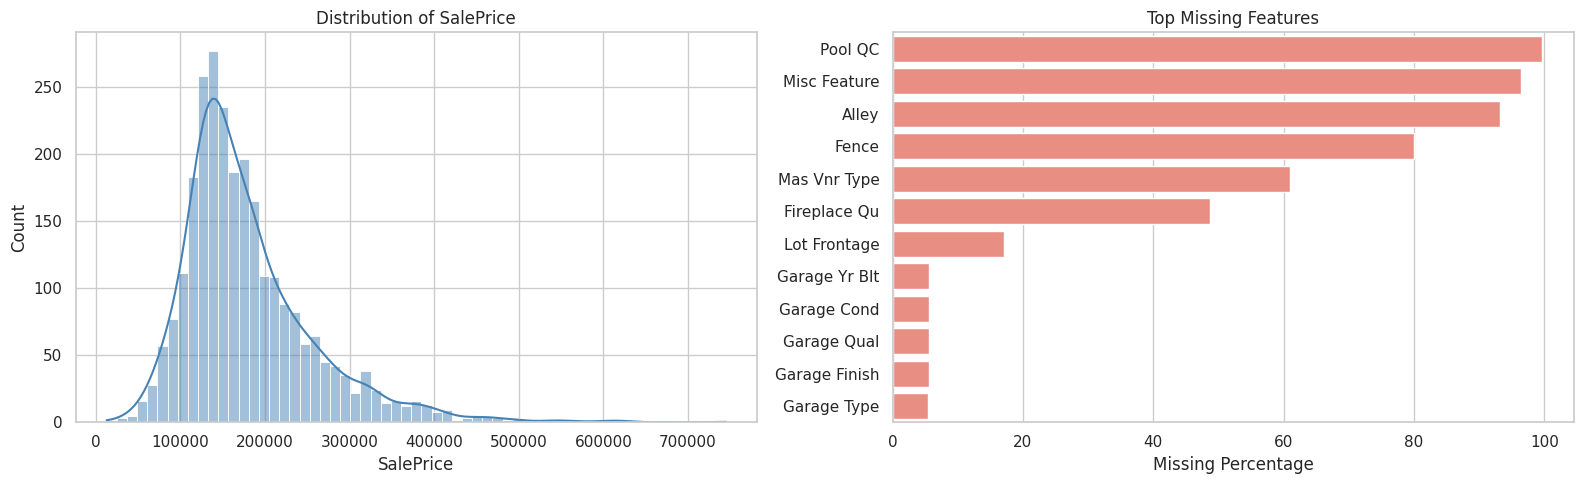

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df["SalePrice"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of SalePrice")

top_missing = missing_summary.query("missing_count > 0").head(12).reset_index()
top_missing.columns = ["feature", "missing_count", "missing_pct"]
sns.barplot(data=top_missing, y="feature", x="missing_pct", ax=axes[1], color="salmon")
axes[1].set_title("Top Missing Features")
axes[1].set_xlabel("Missing Percentage")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


In [6]:
numeric_df = df.select_dtypes(include=np.number)
top_corr = (
    numeric_df.corr(numeric_only=True)["SalePrice"]
    .drop("SalePrice")
    .sort_values(key=np.abs, ascending=False)
)

top_corr.head(15).to_frame(name="correlation_with_saleprice")


,correlation_with_saleprice
Overall Qual,0.805016
Gr Liv Area,0.705482
Garage Cars,0.647223
Garage Area,0.633900
Total Bsmt SF,0.628669
1st Flr SF,0.618247
Year Built,0.562777
Full Bath,0.542386
Year Remod/Add,0.539932
Garage Yr Blt,0.529771


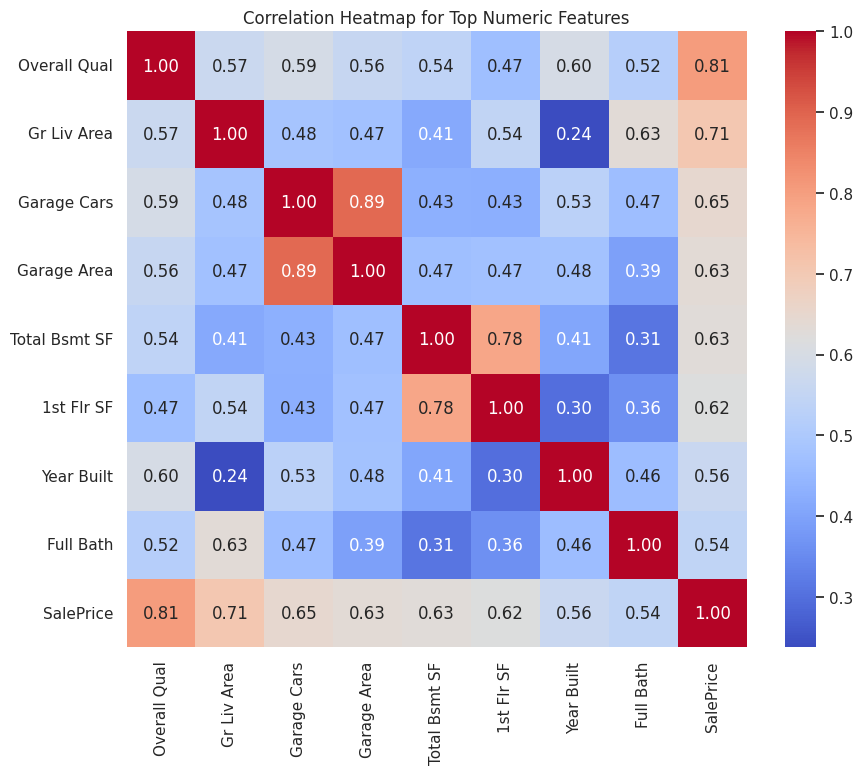

In [7]:
top_corr_features = top_corr.head(8).index.tolist() + ["SalePrice"]
plt.figure(figsize=(10, 8))
sns.heatmap(
    df[top_corr_features].corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap for Top Numeric Features")
plt.show()


## Data Cleaning

Key cleaning decisions:

1. Strip whitespace from column names and text values.
2. Treat blank strings as missing values.
3. Drop `PID` because it is an identifier, not a predictive business feature.
4. Impute missing values inside the modeling pipeline:
   - numeric features: median
   - categorical features: most frequent category

Using a pipeline keeps preprocessing consistent across cross-validation and prevents leakage.


In [8]:
df = df.copy()
df.columns = [col.strip() for col in df.columns]

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()
    df[col] = df[col].replace("", np.nan)

target = "SalePrice"
drop_cols = ["PID"]

X = df.drop(columns=[target] + drop_cols)
y = df[target]

numeric_features = X.select_dtypes(include=np..;p).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")


Numeric features: 36
Categorical features: 43


## Processing

This step prepares the data for modeling:

- split into training and test sets
- build a preprocessing pipeline
- scale numeric features with `StandardScaler`
- one-hot encode categorical variables

Scaling is especially important for regularized models like Ridge and Lasso, because the penalty term depends on coefficient size.


In [9]:
def rmspe(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.sqrt(np.mean(np.square((y_true - y_pred) / y_true))) * 100


rmspe_scorer = make_scorer(rmspe, greater_is_better=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)


## Model Comparison

We first compare the three regression models with cross-validation using the same preprocessing pipeline. This keeps the comparison fair.


In [10]:
model_specs = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(max_iter=50000),
}

cv_results = []

for model_name, model in model_specs.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring={
            "rmspe": rmspe_scorer,
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2",
        },
        n_jobs=-1,
        return_train_score=False,
    )

    cv_results.append(
        {
            "model": model_name,
            "cv_rmspe_mean": -scores["test_rmspe"].mean(),
            "cv_rmspe_std": scores["test_rmspe"].std(),
            "cv_rmse_mean": -scores["test_rmse"].mean(),
            "cv_r2_mean": scores["test_r2"].mean(),
        }
    )

cv_results_df = pd.DataFrame(cv_results).sort_values("cv_rmspe_mean")
cv_results_df


,model,cv_rmspe_mean,cv_rmspe_std,cv_rmse_mean,cv_r2_mean
1,Ridge,17.484638,3.454644,26087.722659,0.887074
2,Lasso,18.776161,4.532696,25442.273584,0.891831
0,LinearRegression,19.238491,4.847338,25876.783009,0.888029


### Cross-Validation with Different Alpha Values

Regularization strength is controlled by `alpha`.

- In **Ridge**, higher alpha shrinks coefficients but does not usually force them to zero.
- In **Lasso**, higher alpha can shrink some coefficients all the way to zero, which can help reduce the feature set.


In [13]:
ridge_alphas = np.logspace(-3, 3, 5)
lasso_alphas = np.logspace(-3, 1.5, 8)

ridge_search = GridSearchCV(
    estimator=Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", Ridge()),
        ]
    ),
    param_grid={"model__alpha": ridge_alphas},
    scoring=rmspe_scorer,
    cv=cv,
    n_jobs=-1,
)

lasso_search = GridSearchCV(
    estimator=Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", Lasso(max_iter=10000)),
        ]
    ),
    param_grid={"model__alpha": lasso_alphas},
    scoring=rmspe_scorer,
    cv=cv,
    n_jobs=-1,
)

ridge_search.fit(X_train, y_train)
lasso_search.fit(X_train, y_train)

print("Best Ridge alpha:", ridge_search.best_params_["model__alpha"])
print("Best Ridge CV RMSPE:", -ridge_search.best_score_)
print()
print("Best Lasso alpha:", lasso_search.best_params_["model__alpha"])
print("Best Lasso CV RMSPE:", -lasso_search.best_score_)


Best Ridge alpha: 31.622776601683793
Best Ridge CV RMSPE: 18.17779257729763

Best Lasso alpha: 31.622776601683793
Best Lasso CV RMSPE: 17.419556401643582


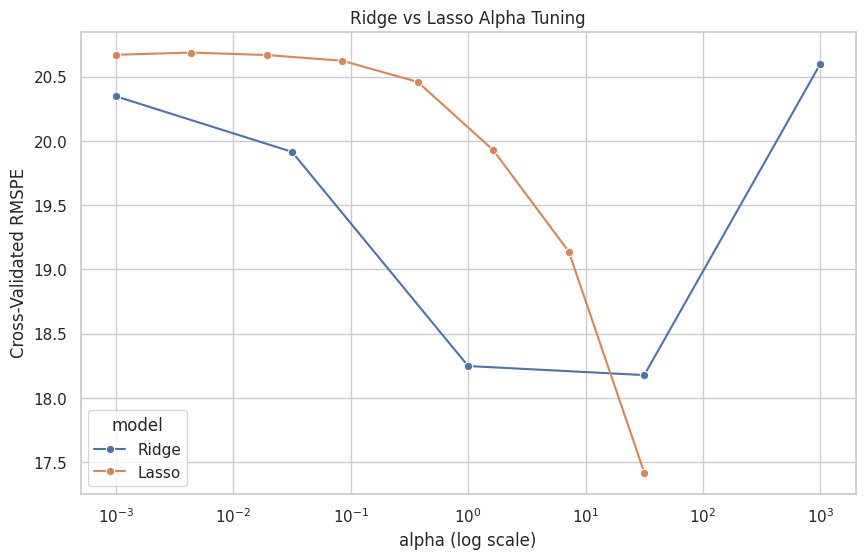

In [14]:
ridge_curve = pd.DataFrame(ridge_search.cv_results_)[["param_model__alpha", "mean_test_score"]].copy()
ridge_curve["model"] = "Ridge"
ridge_curve["mean_rmspe"] = -ridge_curve["mean_test_score"]

lasso_curve = pd.DataFrame(lasso_search.cv_results_)[["param_model__alpha", "mean_test_score"]].copy()
lasso_curve["model"] = "Lasso"
lasso_curve["mean_rmspe"] = -lasso_curve["mean_test_score"]

alpha_curve = pd.concat([ridge_curve, lasso_curve], ignore_index=True)
alpha_curve["param_model__alpha"] = alpha_curve["param_model__alpha"].astype(float)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=alpha_curve,
    x="param_model__alpha",
    y="mean_rmspe",
    hue="model",
    marker="o"
)
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("Cross-Validated RMSPE")
plt.title("Ridge vs Lasso Alpha Tuning")
plt.show()


## Data Visualization / Communication of Results

Now we evaluate the final models on the held-out test set and compare their predictions directly.


In [16]:
final_models = {
    "LinearRegression": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LinearRegression()),
        ]
    ),
    "Ridge": ridge_search.best_estimator_,
    "Lasso": lasso_search.best_estimator_,
}

test_results = []
prediction_frame = pd.DataFrame({"Actual": y_test.reset_index(drop=True)})

for model_name, fitted_model in final_models.items():
    fitted_model.fit(X_train, y_train)
    preds = fitted_model.predict(X_test)

    prediction_frame[model_name] = preds

    test_results.append(
        {
            "model": model_name,
            "test_rmspe": rmspe(y_test, preds),
            "test_rmse": mean_squared_error(y_test, preds) ** 0.5,
            "test_r2": r2_score(y_test, preds),
        }
    )

test_results_df = pd.DataFrame(test_results).sort_values("test_rmspe")
test_results_df


,model,test_rmspe,test_rmse,test_r2
2,Lasso,11.408238,24341.493064,0.914185
0,LinearRegression,11.992325,22532.887107,0.926464
1,Ridge,12.127744,27425.097267,0.891066


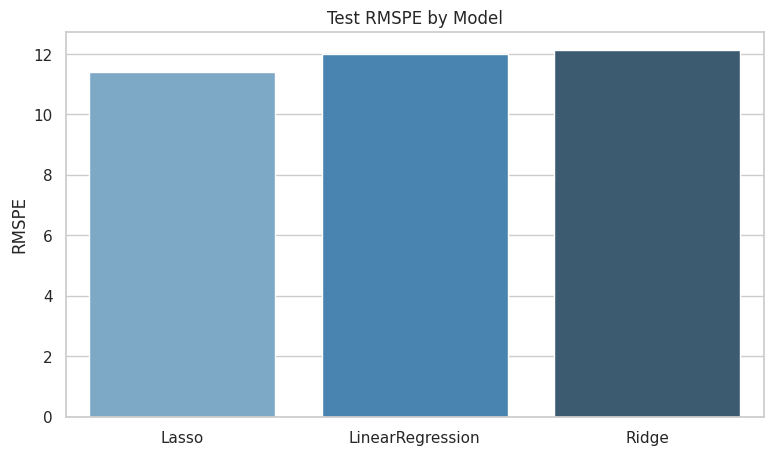

In [17]:
plt.figure(figsize=(9, 5))
sns.barplot(data=test_results_df, x="model", y="test_rmspe", palette="Blues_d")
plt.title("Test RMSPE by Model")
plt.ylabel("RMSPE")
plt.xlabel("")
plt.show()


In [18]:
sample_predictions = prediction_frame.head(10).copy()
sample_predictions["LinearRegression_ErrorPct"] = (
    (sample_predictions["Actual"] - sample_predictions["LinearRegression"]).abs()
    / sample_predictions["Actual"]
    * 100
)
sample_predictions["Ridge_ErrorPct"] = (
    (sample_predictions["Actual"] - sample_predictions["Ridge"]).abs()
    / sample_predictions["Actual"]
    * 100
)
sample_predictions["Lasso_ErrorPct"] = (
    (sample_predictions["Actual"] - sample_predictions["Lasso"]).abs()
    / sample_predictions["Actual"]
    * 100
)

sample_predictions.round(2)


,Actual,LinearRegression,Ridge,Lasso,LinearRegression_ErrorPct,Ridge_ErrorPct,Lasso_ErrorPct
0,275000,276721.53,270675.19,276364.85,0.63,1.57,0.50
1,122000,109274.08,107850.82,106076.92,10.43,11.60,13.05
2,156932,171653.12,170747.18,171863.40,9.38,8.80,9.51
3,112000,113169.69,121162.92,114301.10,1.04,8.18,2.05
4,189000,203896.31,211701.38,205678.88,7.88,12.01,8.82
5,325300,317871.98,320971.29,317120.43,2.28,1.33,2.51
6,105000,101106.45,104543.12,99392.15,3.71,0.44,5.34
7,386250,408581.97,404580.13,406251.21,5.78,4.75,5.18
8,212000,238823.35,219713.08,237529.99,12.65,3.64,12.04
9,167000,195145.25,189743.22,192248.58,16.85,13.62,15.12


## Interpreting the Regularized Models

Lasso is especially useful for identifying a smaller set of influential variables because it can drive weaker coefficients to exactly zero.


In [19]:
best_ridge = ridge_search.best_estimator_
best_lasso = lasso_search.best_estimator_

feature_names = best_ridge.named_steps["preprocessor"].get_feature_names_out()

ridge_coefs = pd.Series(
    best_ridge.named_steps["model"].coef_,
    index=feature_names,
).sort_values(key=np.abs, ascending=False)

lasso_coefs = pd.Series(
    best_lasso.named_steps["model"].coef_,
    index=feature_names,
).sort_values(key=np.abs, ascending=False)

print("Top 15 Ridge coefficients")
display(ridge_coefs.head(15).to_frame("coefficient"))

print("Top 15 Lasso coefficients")
display(lasso_coefs.head(15).to_frame("coefficient"))

non_zero_lasso = (lasso_coefs != 0).sum()
print(f"Lasso retained {non_zero_lasso} non-zero coefficients out of {len(lasso_coefs)} engineered features.")


Top 15 Ridge coefficients


,coefficient
cat__Neighborhood_NoRidge,17281.501024
cat__Neighborhood_NridgHt,17167.848538
cat__Neighborhood_StoneBr,16728.817524
cat__Kitchen Qual_Ex,16636.994156
num__Overall Qual,14224.787377
cat__Bsmt Qual_Ex,12596.056564
num__Gr Liv Area,12356.567939
cat__Neighborhood_Edwards,-11500.835639
cat__Roof Matl_ClyTile,-11078.970574
cat__Bsmt Exposure_Gd,10086.115123


Top 15 Lasso coefficients


,coefficient
cat__Roof Matl_ClyTile,-476485.910417
cat__Condition 2_PosN,-81607.712116
cat__Condition 2_PosA,47128.378251
cat__Neighborhood_StoneBr,41121.378036
cat__Roof Matl_WdShngl,40024.767406
cat__Neighborhood_NoRidge,33213.919901
cat__Neighborhood_NridgHt,26299.539780
num__Gr Liv Area,24676.536061
cat__Kitchen Qual_Ex,23765.262445
cat__Exter Qual_Ex,18246.274555


Lasso retained 153 non-zero coefficients out of 298 engineered features.


## Conclusion

This notebook followed the full data science process:

- defined the problem
- collected and reviewed the data
- explored the data visually
- cleaned missing values and text inconsistencies
- processed features with scaling and encoding
- compared linear, Ridge, and Lasso regression
- tuned alpha values using cross-validation
- evaluated results on a holdout test set

### Key takeaways
- `LinearRegression` acts as the baseline.
- `Ridge` usually improves stability by shrinking coefficients without removing many variables.
- `Lasso` can create a more compact model by shrinking some coefficients to zero.
- The best model should be chosen based on the **lowest RMSPE**, not just RMSE or R-squared.

If you want to push the project further, good next steps would be:
- testing a smaller hand-selected feature set
- engineering a few interaction features
- comparing results with log-transformed target values
